# RF across groups

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(dunn.test)
quiet_library(ggplot2)

## Read in metadata

In [3]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [4]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

## Cross-sectional: HC1|NONC|CONV|ERA

In [5]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007')

outCols <- c('Status_Long')

In [6]:
meta_xsec <- meta %>%
    select(-any_of(outCols)) %>%
    mutate(Status = ifelse(Status_Xsec == 'early_RA' & subject.subjectGuid %in% conv, 
                           'converter', 
                           ifelse(Status_Xsec == 'at_risk' & !subject.subjectGuid %in% conv,
                                  'non_converter', 
                                  Status_Xsec))) %>%
    filter(Status %in% c('ALTRA_healthy', 'non_converter', 'converter', 'early_RA'), # remove original at_risk distinction
           sample.sampleKitGuid != 'KT04113') # remove duplicate CU1009 (post-conversion) entry to match other analyses

In [7]:
table(meta_xsec$Status, meta_xsec$Status_Xsec)

               
                ALTRA_healthy at_risk early_RA
  ALTRA_healthy            38       0        0
  converter                 0       0       16
  early_RA                  0       0       11
  non_converter             0      31        0

## Visualizations

In [8]:
plotBoxplot <- function(df, y, int, ylab) {

    a <- df %>%
        filter(.data[[y]] != '999')

    ggplot(a, aes(x=Status, 
                  y=.data[[y]],
                  colour=Status)) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(position = position_jitter(0.2), 
                    cex = 1.5) + 
        geom_hline(yintercept = int, 
                   linetype = 'dashed') + 
        scale_colour_manual(breaks = c('ALTRA_healthy', 
                                       'non_converter', 
                                       'converter',
                                       'early_RA'), 
                            values = c('#4C8CBD', 
                                       '#FFCD70',
                                       '#FF540A', 
                                       '#840032')) + 
        scale_x_discrete(breaks = c('ALTRA_healthy', 
                                    'non_converter', 
                                    'converter',
                                    'early_RA'),
                         labels = c('HC1', 
                                    'NONC',
                                    'CONV',
                                    'ERA'), 
                         limits = c('ALTRA_healthy', 
                                    'non_converter', 
                                    'converter',
                                    'early_RA')) + 
        labs(x = 'Status', 
             y = ylab) +
        theme_classic() + 
        theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
               legend.position = 'none',
               axis.text.y = element_text(size = 12),
               axis.text.x = element_text(size = 12), 
               axis.title.y = element_text(size = 12), 
               axis.title.x = element_text(size = 12))

}

#### RF-IgM

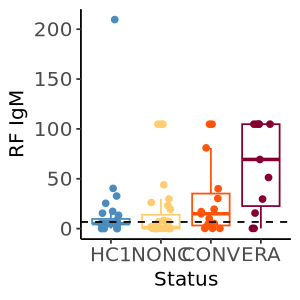

In [9]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5) # default 7x7

p <- plotBoxplot(meta_xsec, 'rfigm_result', 6.7, 'RF IgM')

print(p)

In [10]:
ggsave(filename = 'RFIgM.pdf', 
       path = 'Figures',
       p,
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

In [11]:
kruskal.test(rfigm_result ~ Status, 
             data = meta_xsec)


	Kruskal-Wallis rank sum test

data:  rfigm_result by Status
Kruskal-Wallis chi-squared = 12.161, df = 3, p-value = 0.006851


In [12]:
dunn.test(meta_xsec$rfigm_result, meta_xsec$Status, 
          method = 'Bonferroni', 
          alpha = 0.05, 
          altp = TRUE)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 12.1611, df = 3, p-value = 0.01


                           Comparison of x by group                            
                                 (Bonferroni)                                  
Col Mean-|
Row Mean |   ALTRA_he   converte   early_RA
---------+---------------------------------
converte |  -0.093528
         |     1.0000
         |
early_RA |  -1.276306  -1.054299
         |     1.0000     1.0000
         |
non_conv |   2.537804   2.125017   3.040538
         |     0.0669     0.2015    0.0142*

alpha = 0.05
Reject Ho if p <= alpha


#### RF-IgA

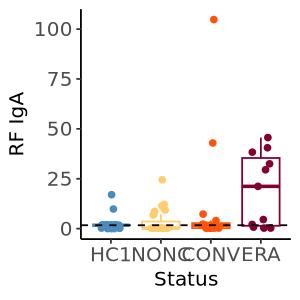

In [13]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5) # default 7x7

p <- plotBoxplot(meta_xsec, 'rfiga_result', 1.7, 'RF IgA')

print(p)

In [14]:
ggsave(filename = 'RFIgA.pdf', 
       path = 'Figures',
       p,
       device = 'pdf', 
       width = 2.5, 
       height = 2.5, 
       units = 'in')

In [15]:
kruskal.test(rfiga_result ~ Status, 
             data = meta_xsec)


	Kruskal-Wallis rank sum test

data:  rfiga_result by Status
Kruskal-Wallis chi-squared = 12.945, df = 3, p-value = 0.004757


In [16]:
dunn.test(meta_xsec$rfiga_result, meta_xsec$Status, 
          method = 'Bonferroni', 
          alpha = 0.05, 
          altp = TRUE)

  Kruskal-Wallis rank sum test

data: x and group
Kruskal-Wallis chi-squared = 12.945, df = 3, p-value = 0


                           Comparison of x by group                            
                                 (Bonferroni)                                  
Col Mean-|
Row Mean |   ALTRA_he   converte   early_RA
---------+---------------------------------
converte |   0.006194
         |     1.0000
         |
early_RA |  -2.290806  -2.026447
         |     0.1318     0.2563
         |
non_conv |   1.835978   1.464940   3.546521
         |     0.3982     0.8576    0.0023*

alpha = 0.05
Reject Ho if p <= alpha


In [17]:
sessionInfo()

Warning message:
“Your system is mis-configured: ‘/var/db/timezone/localtime’ is not a symlink”
Warning message:
“‘/var/db/timezone/localtime’ is not identical to any known timezone file”


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: NA
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_3.5.1   dunn.test_1.3.6 qvalue_2.34.0   dplyr_1.1.4    
[5] hise_2.16.0    

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] tidyselect_1.2.1  Rcpp_1.0.13       IRdisplay_1.1     stringr_1.5.1    
 [9] bitops_1.0-8      assertthat_0.2.1  text